# Stock Market Data Analysis

## Project Overview

This project analyzes the historical stock market performance of five major companies:

- Apple (AAPL)
- Microsoft (MSFT)
- NVIDIA (NVDA)
- Amazon (AMZN)
- Tesla (TSLA)

The analysis is based on approximately three years of historical daily stock market data collected from Yahoo Finance.

## Objectives

The main objectives of this project are to:

- Analyze historical stock price movements.
- Compare stock performance across companies.
- Calculate daily and cumulative returns.
- Evaluate volatility and historical risk.
- Analyze tail risk using Kurtosis.
- Examine correlations between stock returns.
- Evaluate risk-adjusted performance using the Sharpe Ratio.
- Measure downside risk using Maximum Drawdown.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Plotly
- yFinance

> **Disclaimer:** This project is for educational and analytical purposes only and does not constitute financial or investment advice.

In [ ]:
import pandas as pd
import numpy as np
from plotly import express as px
import seaborn as sns

import yfinance
import mplfinance
import statsmodels.api as sm
import scipy.stats as stats

import datetime as dt
import os

pd.options.display.float_format = '{:,.2f}'.format
pd.options.display.max_columns = 1000
pd.options.display.max_rows = 1000

sns.set()

### Downloading Data From Yahoo

In [3]:
stocknames = ['AAPL', 'MSFT','NVDA', 'AMZN', 'TSLA']
startdate = '2023-01-01'
enddate = dt.datetime.now().date()
interval = '1d'

In [4]:
for stock in stocknames:
    df = yfinance.download(stock, interval= interval, period= '3y')
    df.to_csv('{}.csv'.format(stock))

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [5]:
df = pd.read_csv('AAPL.csv')
df.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
1,Date,NaN,NaN,NaN,NaN,NaN
2,2023-09-01,186.9317169189453,187.3855699191495,185.76745585396847,186.96131537308187,45766500
3,2023-09-05,187.16851806640625,187.44478036173828,185.10641198511868,185.76746926717502,45280000
4,2023-09-06,180.46914672851562,186.32988234003622,179.04836051297525,185.88587535630464,81755800


# Cleaning

In [6]:
# Companies
companies = ["AAPL", "MSFT", "NVDA", "AMZN", "TSLA"]

def clean_stock_data(file_name):
    
    df = pd.read_csv(file_name)

    # Remove the first two unnecessary rows
    df = df.iloc[2:].copy()

    # Rename columns
    df.columns = [
        "Date",
        "Close",
        "High",
        "Low",
        "Open",
        "Volume"
    ]

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

    numeric_columns = ["Close", "High", "Low", "Open", "Volume"]

    for col in numeric_columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df.dropna(inplace=True)

    df.drop_duplicates(inplace=True)

    df.sort_values("Date", inplace=True)

    df.reset_index(drop=True, inplace=True)

    return df


# Clean all companies
stock_data = {}

for company in companies:
    stock_data[company] = clean_stock_data(f"{company}.csv")


In [7]:
# Display first rows of each company
for company, df in stock_data.items():
    print(f"\n========== {company} ==========")
    print(df.head())


========== AAPL ==========
        Date  Close   High    Low   Open     Volume
0 2023-09-01 186.93 187.39 185.77 186.96   45766500
1 2023-09-05 187.17 187.44 185.11 185.77   45280000
2 2023-09-06 180.47 186.33 179.05 185.89   81755800
3 2023-09-07 175.19 175.83 171.22 172.84  112488800
4 2023-09-08 175.80 177.83 175.42 175.97   65551300

========== MSFT ==========
        Date  Close   High    Low   Open    Volume
0 2023-09-01 321.14 324.39 319.30 323.73  14942000
1 2023-09-05 325.92 327.19 321.14 321.47  18553900
2 2023-09-06 325.26 326.81 322.62 325.75  17535800
3 2023-09-07 322.36 325.46 321.50 323.71  18381000
4 2023-09-08 326.62 328.47 321.92 322.54  19530100

========== NVDA ==========
        Date  Close  High   Low  Open     Volume
0 2023-09-01  48.41 49.70 48.05 49.67  463830000
1 2023-09-05  48.45 48.76 47.77 48.13  382653000
2 2023-09-06  46.97 48.46 46.49 48.35  468670000
3 2023-09-07  46.15 46.26 45.07 45.44  433330000
4 2023-09-08  45.49 46.52 45.19 45.86  473069000

===

In [8]:
combined_close = stock_data[companies[0]][["Date", "Close"]].copy()

combined_close.set_index("Date", inplace=True)

combined_close.rename(
    columns={"Close": companies[0]},
    inplace=True
)

for company in companies[1:]:

    temp = stock_data[company][["Date", "Close"]].copy()

    temp.set_index("Date", inplace=True)

    temp.rename(
        columns={"Close": company},
        inplace=True
    )

    combined_close = combined_close.join(
        temp,
        how="inner"
    )

combined_close.head()

,AAPL,MSFT,NVDA,AMZN,TSLA
Date,,,,,
2023-09-01,186.93,321.14,48.41,138.12,245.01
2023-09-05,187.17,325.92,48.45,137.27,256.49
2023-09-06,180.47,325.26,46.97,135.36,251.92
2023-09-07,175.19,322.36,46.15,137.85,251.49
2023-09-08,175.80,326.62,45.49,138.23,248.50


In [9]:
combined_close.isna().sum()

AAPL    0
MSFT    0
NVDA    0
AMZN    0
TSLA    0
dtype: int64

In [10]:
combined_close.describe().T

,count,mean,std,min,25%,50%,75%,max
AAPL,751.00,228.56,41.58,163.22,192.50,224.92,257.57,339.79
MSFT,751.00,421.88,51.05,305.00,390.62,412.77,456.33,537.65
NVDA,751.00,136.23,52.26,40.25,99.52,135.36,182.06,235.47
AMZN,751.00,202.98,35.64,119.57,179.60,206.65,229.28,284.02
TSLA,751.00,309.59,92.05,142.05,230.92,315.65,396.37,489.88


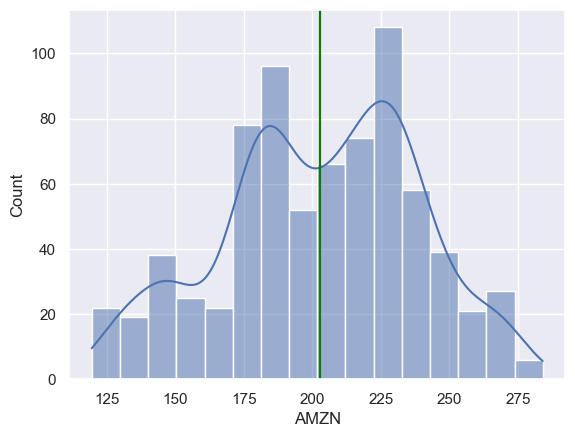

In [11]:
import matplotlib.pyplot as plt
sns.histplot(data= combined_close, x= 'AMZN', kde= True)
plt.axvline(combined_close["AMZN"].mean(), color= 'red')
plt.axvline(combined_close["AMZN"].mean(), color= 'green')

## Look at the prices

In [12]:
fig = px.line(
    data_frame=combined_close,
    title="Close Prices",
    width=1100,
    height=500
)

fig.show()

In [13]:
df = combined_close

In [14]:
norm = df / df.iloc[0,:]
norm.head()

,AAPL,MSFT,NVDA,AMZN,TSLA
Date,,,,,
2023-09-01,1.00,1.00,1.00,1.00,1.00
2023-09-05,1.00,1.01,1.00,0.99,1.05
2023-09-06,0.97,1.01,0.97,0.98,1.03
2023-09-07,0.94,1.00,0.95,1.00,1.03
2023-09-08,0.94,1.02,0.94,1.00,1.01


In [52]:
fig = px.line(
    norm,
    width=1100,
    height=500
)
fig.update_layout(title= "Relative Stock Performance (Normalized to Starting Price)", 
                    xaxis_title= 'Date', yaxis_title= 'Normalized price' )
fig.show()

<Axes: xlabel='TSLA', ylabel='Count'>

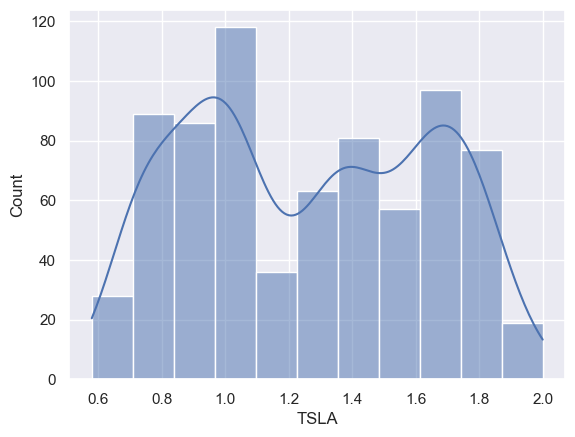

In [16]:
sns.histplot(data= norm, x= norm.TSLA, kde= True)

## TSLA  AMA50 Indicator


# Rollingmean

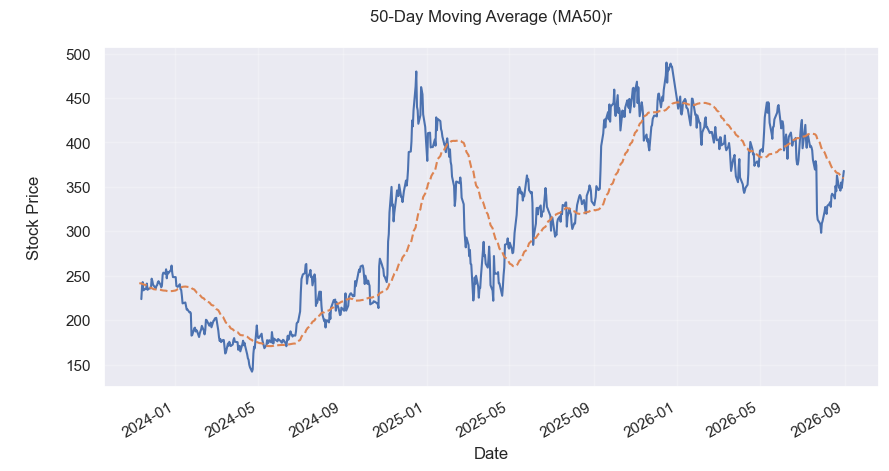

In [62]:
rollingmean = df.TSLA.rolling(50).mean()
fig, ax = plt.subplots(figsize= (10,5))
df.iloc[50:]['TSLA'].plot(ax=ax)
ax.set_title('50-Day Moving Average (MA50)r\n')
ax.set_xlabel('Date')
ax.set_ylabel('\nStock Price\n')
rollingmean.plot(ax=ax, linestyle= '--')
plt.grid(alpha= 0.25)

## AMZN  AMA50 Indicator

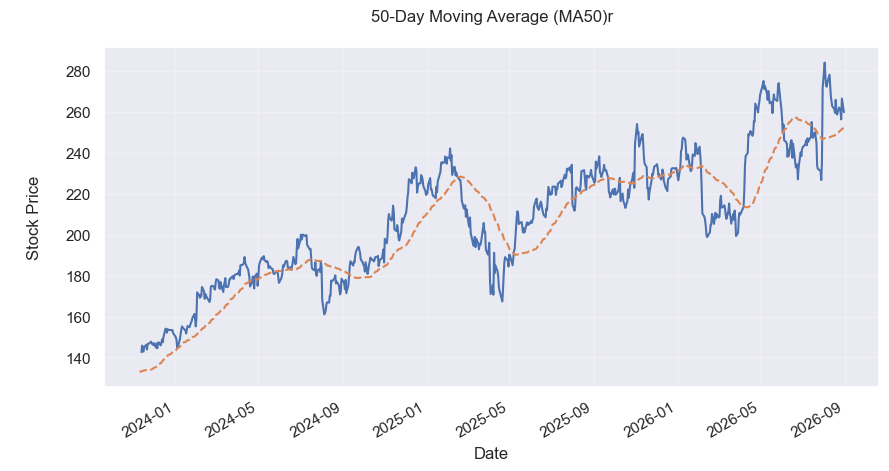

In [63]:
rollingmean = df.AMZN.rolling(50).mean()
fig, ax = plt.subplots(figsize= (10,5))
df.iloc[50:]['AMZN'].plot(ax=ax)
ax.set_title('50-Day Moving Average (MA50)r\n')
ax.set_xlabel('Date')
ax.set_ylabel('\nStock Price\n')
rollingmean.plot(ax=ax, linestyle= '--')
plt.grid(alpha= 0.25)

##  MSFT AMA50 Indicator

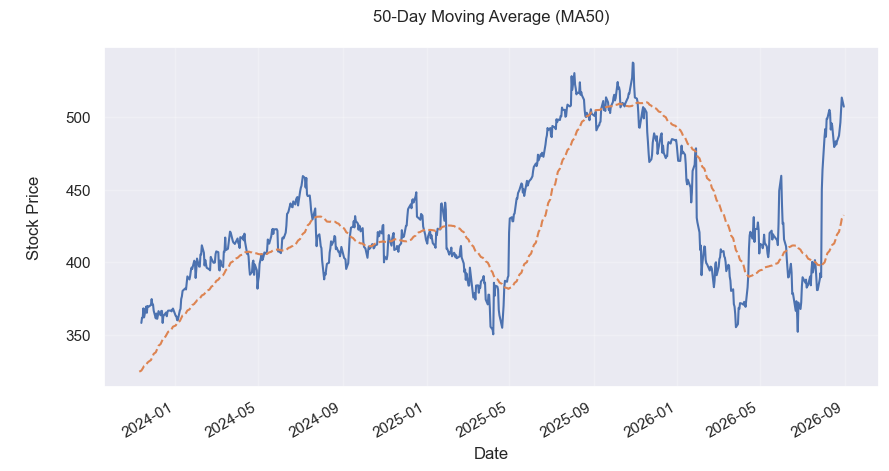

In [64]:
rollingmean = df.MSFT.rolling(50).mean()
fig, ax = plt.subplots(figsize= (10,5))
df.iloc[50:]['MSFT'].plot(ax=ax)
ax.set_title('50-Day Moving Average (MA50)\n')
ax.set_xlabel('Date')
ax.set_ylabel('\nStock Price\n')
rollingmean.plot(ax=ax, linestyle= '--')
plt.grid(alpha= 0.25)

##  NVDA AMA50 Indicator

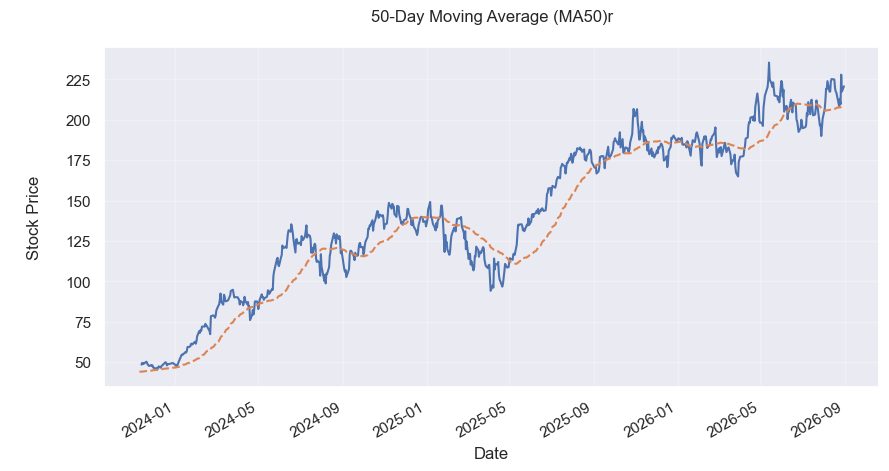

In [65]:
rollingmean = df.NVDA.rolling(50).mean()
fig, ax = plt.subplots(figsize= (10,5))
df.iloc[50:]['NVDA'].plot(ax=ax)
ax.set_title('50-Day Moving Average (MA50)r\n')
ax.set_xlabel('Date')
ax.set_ylabel('\nStock Price\n')
rollingmean.plot(ax=ax, linestyle= '--')
plt.grid(alpha= 0.25)

##  AAPL AMA50 Indicator

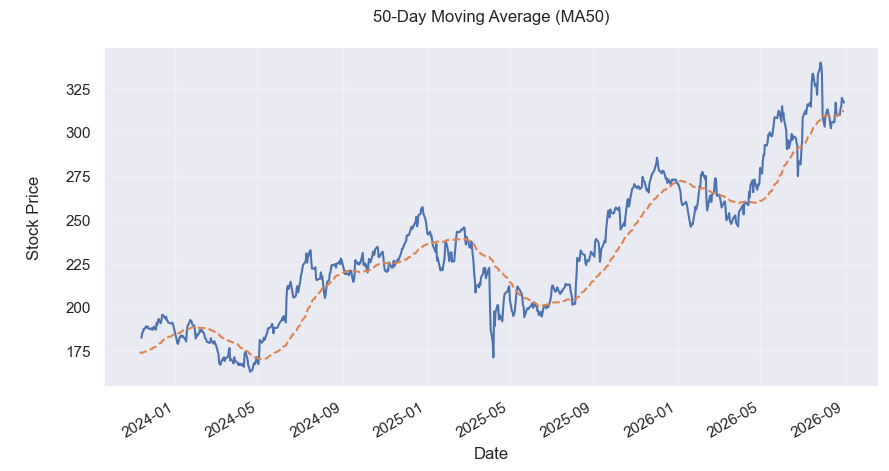

In [66]:
rollingmean = df.AAPL.rolling(50).mean()
fig, ax = plt.subplots(figsize= (10,5))
df.iloc[50:]['AAPL'].plot(ax=ax)
ax.set_title('50-Day Moving Average (MA50)\n')
ax.set_xlabel('Date')
ax.set_ylabel('\nStock Price\n')
rollingmean.plot(ax=ax, linestyle= '--')
plt.grid(alpha= 0.25)

## Rolling Statistics

<Axes: title={'center': 'Rolling Mean'}, xlabel='Date'>

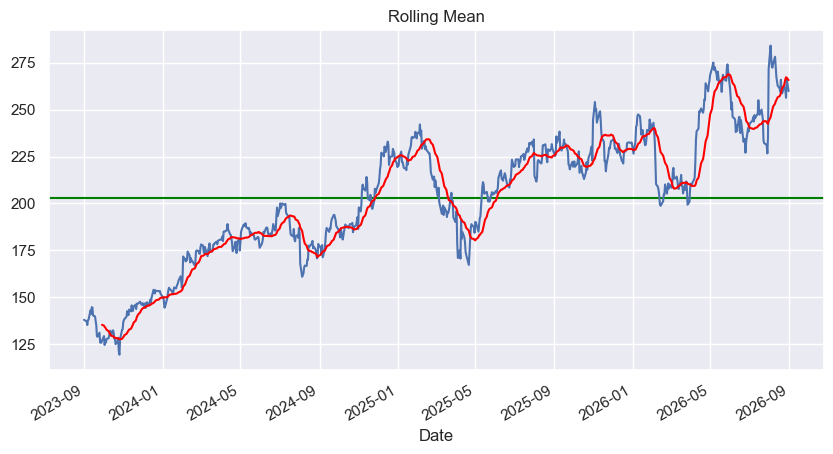

In [18]:
rollingmean = df.AMZN.rolling(20).mean()
fig, ax = plt.subplots(figsize= (10,5))
plt.title('Rolling Mean')
plt.axhline(df.AMZN.mean(), color= 'green')
df.AMZN.plot(ax=ax)
rollingmean.plot(ax=ax, color= 'red')

## AMZN Bollinger Bands Indicator

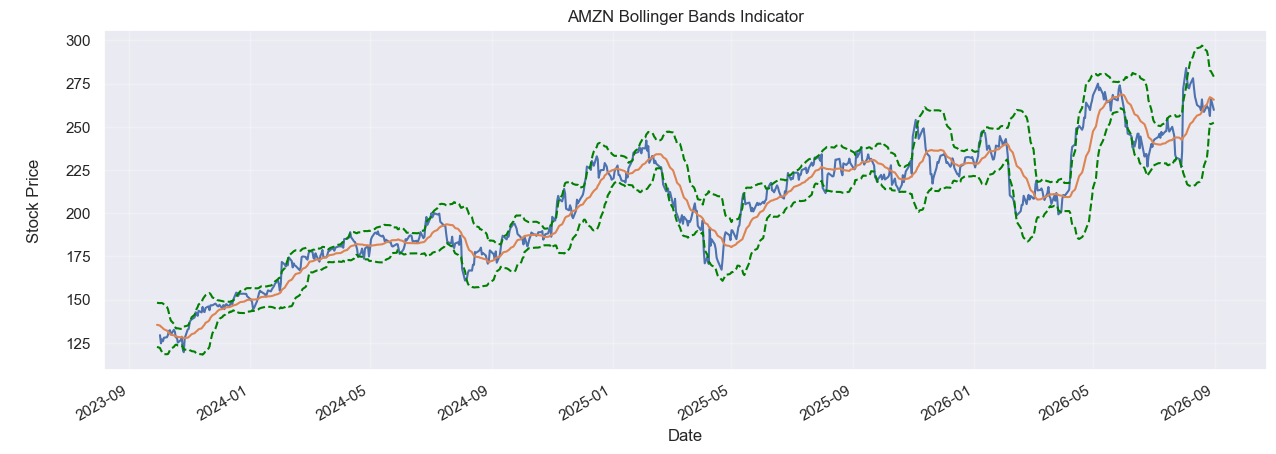

In [19]:
rollingmean = df.AMZN.rolling(20).mean()
rollingstd = df.AMZN.rolling(20).std()
lowerbound = rollingmean - (2 * rollingstd)
upperbound = rollingmean + (2 * rollingstd)
fig, ax = plt.subplots(figsize= (15,5))
df.iloc[20:]['AMZN'].plot()
plt.title('AMZN Bollinger Bands Indicator')
plt.xlabel('Date')
plt.ylabel('\nStock Price\n')
rollingmean.plot(linestyle= '-')
lowerbound.plot(linestyle= '--', color= 'green')
upperbound.plot(linestyle= '--', color= 'green')
plt.grid(alpha= 0.25)

## AAPL Bollinger Bands Indicator

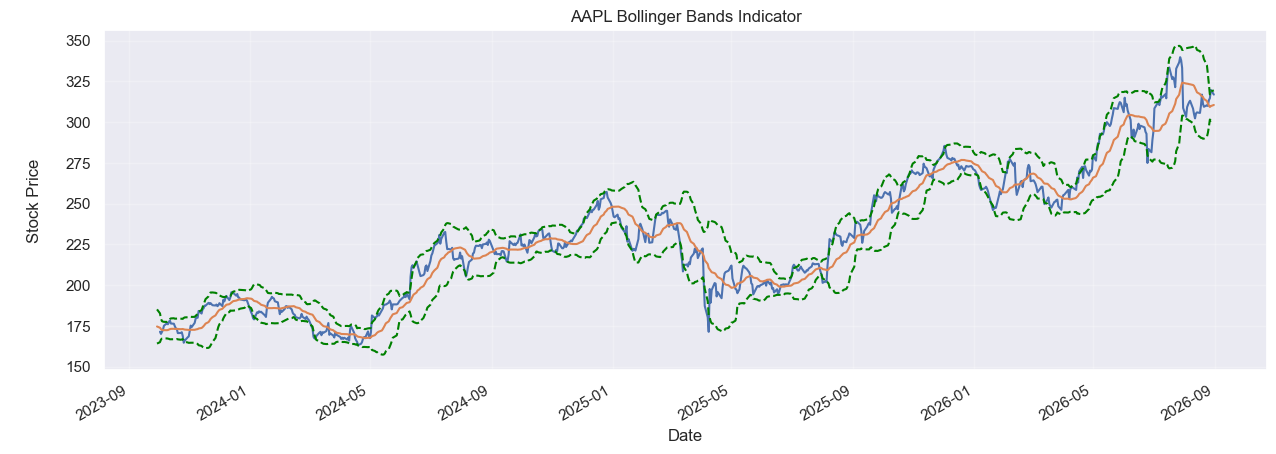

In [38]:
rollingmean = df.AAPL.rolling(20).mean()
rollingstd = df.AAPL.rolling(20).std()
lowerbound = rollingmean - (2 * rollingstd)
upperbound = rollingmean + (2 * rollingstd)
fig, ax = plt.subplots(figsize= (15,5))
df.iloc[20:]['AAPL'].plot()
plt.title('AAPL Bollinger Bands Indicator')
plt.xlabel('Date')
plt.ylabel('\nStock Price\n')
rollingmean.plot(linestyle= '-')
lowerbound.plot(linestyle= '--', color= 'green')
upperbound.plot(linestyle= '--', color= 'green')
plt.grid(alpha= 0.25)

## MSFT Bollinger Bands Indicator

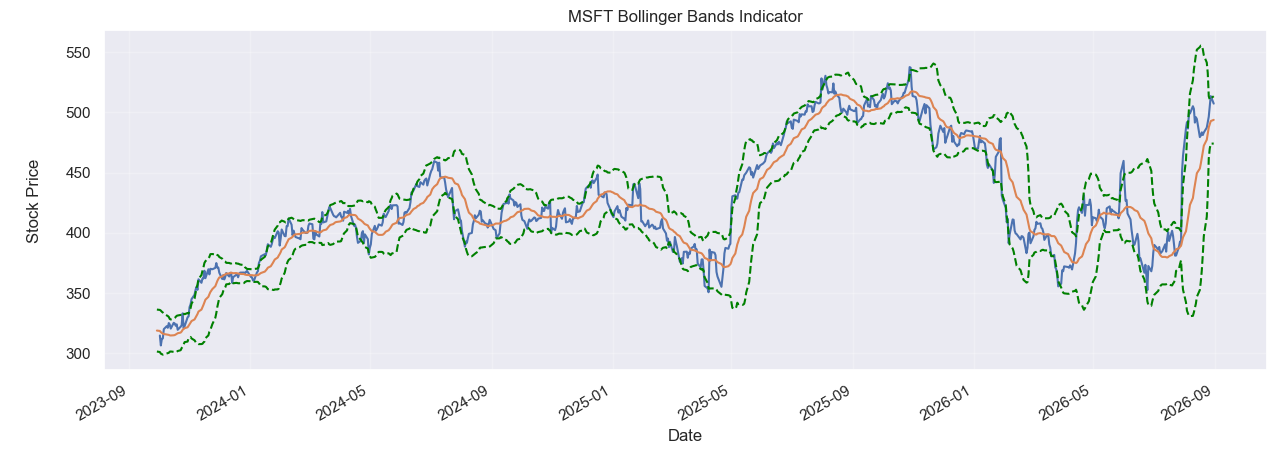

In [39]:
rollingmean = df.MSFT.rolling(20).mean()
rollingstd = df.MSFT.rolling(20).std()
lowerbound = rollingmean - (2 * rollingstd)
upperbound = rollingmean + (2 * rollingstd)
fig, ax = plt.subplots(figsize= (15,5))
df.iloc[20:]['MSFT'].plot()
plt.title('MSFT Bollinger Bands Indicator')
plt.xlabel('Date')
plt.ylabel('\nStock Price\n')
rollingmean.plot(linestyle= '-')
lowerbound.plot(linestyle= '--', color= 'green')
upperbound.plot(linestyle= '--', color= 'green')
plt.grid(alpha= 0.25)

## NVDA Bollinger Bands Indicator

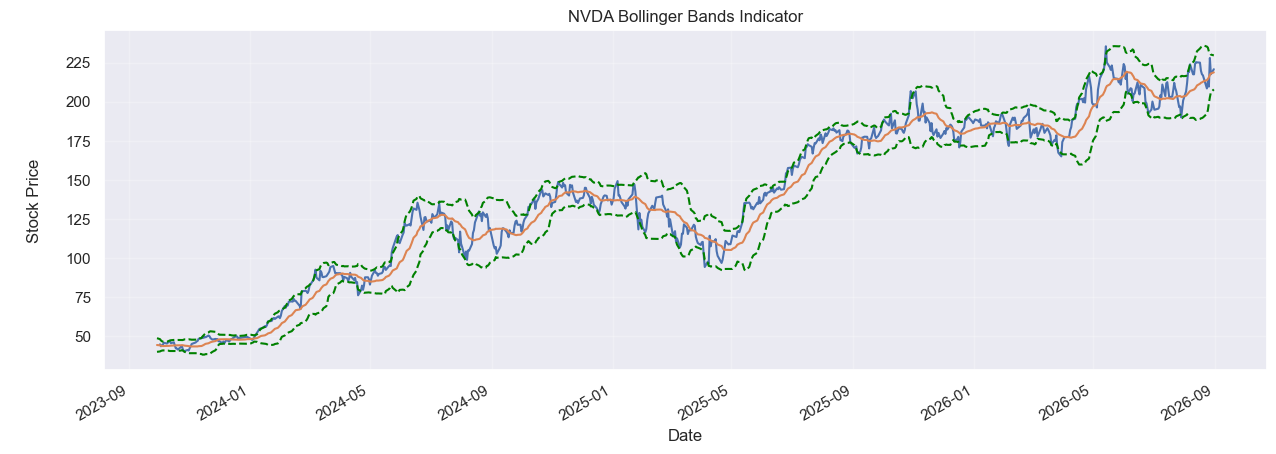

In [40]:
rollingmean = df.NVDA.rolling(20).mean()
rollingstd = df.NVDA.rolling(20).std()
lowerbound = rollingmean - (2 * rollingstd)
upperbound = rollingmean + (2 * rollingstd)
fig, ax = plt.subplots(figsize= (15,5))
df.iloc[20:]['NVDA'].plot()
plt.title('NVDA Bollinger Bands Indicator')
plt.xlabel('Date')
plt.ylabel('\nStock Price\n')
rollingmean.plot(linestyle= '-')
lowerbound.plot(linestyle= '--', color= 'green')
upperbound.plot(linestyle= '--', color= 'green')
plt.grid(alpha= 0.25)

## TSLA Bollinger Bands Indicator

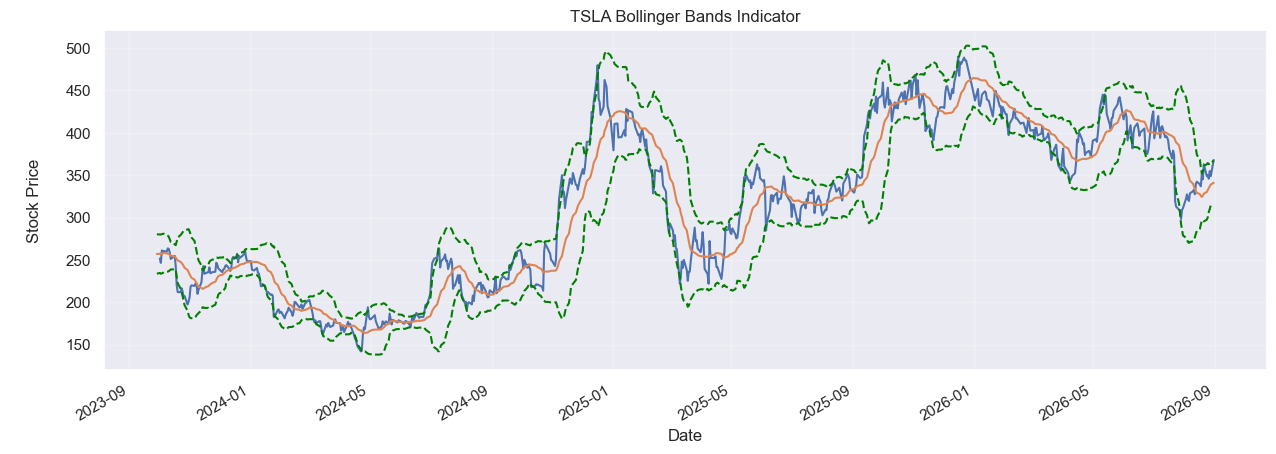

In [41]:
rollingmean = df.TSLA.rolling(20).mean()
rollingstd = df.TSLA.rolling(20).std()
lowerbound = rollingmean - (2 * rollingstd)
upperbound = rollingmean + (2 * rollingstd)
fig, ax = plt.subplots(figsize= (15,5))
df.iloc[20:]['TSLA'].plot()
plt.title('TSLA Bollinger Bands Indicator')
plt.xlabel('Date')
plt.ylabel('\nStock Price\n')
rollingmean.plot(linestyle= '-')
lowerbound.plot(linestyle= '--', color= 'green')
upperbound.plot(linestyle= '--', color= 'green')
plt.grid(alpha= 0.25)

# Metrics
* Daily Returns
* Cummulative Returns
* Sharpe Ratio

In [20]:
df.head()

,AAPL,MSFT,NVDA,AMZN,TSLA
Date,,,,,
2023-09-01,186.93,321.14,48.41,138.12,245.01
2023-09-05,187.17,325.92,48.45,137.27,256.49
2023-09-06,180.47,325.26,46.97,135.36,251.92
2023-09-07,175.19,322.36,46.15,137.85,251.49
2023-09-08,175.80,326.62,45.49,138.23,248.50


In [21]:
Daily_Returns = df.pct_change()
Daily_Returns.iloc[0,:] = 0 # NAN for all coulmns = 0
Daily_Returns.head()

,AAPL,MSFT,NVDA,AMZN,TSLA
Date,,,,,
2023-09-01,0.00,0.00,0.00,0.00,0.00
2023-09-05,0.00,0.01,0.00,-0.01,0.05
2023-09-06,-0.04,-0.00,-0.03,-0.01,-0.02
2023-09-07,-0.03,-0.01,-0.02,0.02,-0.00
2023-09-08,0.00,0.01,-0.01,0.00,-0.01


In [22]:
Daily_Returns.describe().T

,count,mean,std,min,25%,50%,75%,max
AAPL,751.00,0.00,0.02,-0.09,-0.01,0.00,0.01,0.15
MSFT,751.00,0.00,0.02,-0.10,-0.01,0.00,0.01,0.16
NVDA,751.00,0.00,0.03,-0.17,-0.01,0.00,0.02,0.19
AMZN,751.00,0.00,0.02,-0.09,-0.01,0.00,0.01,0.15
TSLA,751.00,0.00,0.04,-0.15,-0.02,0.00,0.02,0.23


In [50]:
Daily_Returns.mean()

AAPL   0.00
MSFT   0.00
NVDA   0.00
AMZN   0.00
TSLA   0.00
dtype: float64

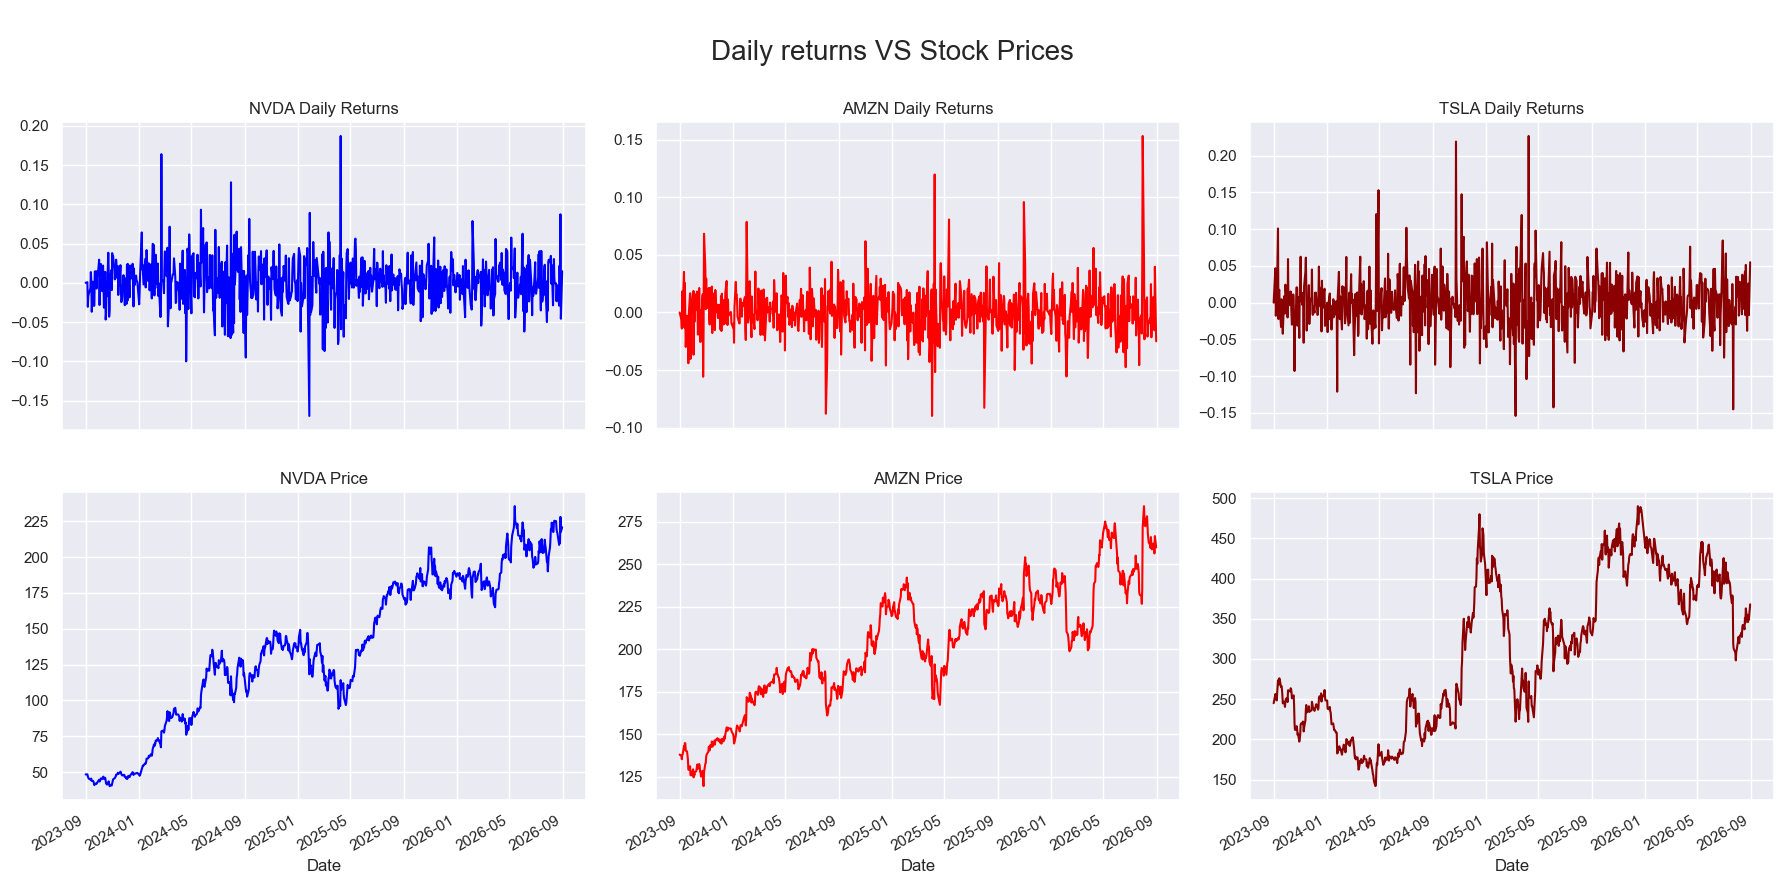

In [23]:
fig, ax = plt.subplots(2,3, figsize= (18,9), sharex= True)

Daily_Returns.NVDA.plot(ax=ax[0][0], color= 'blue')
ax[0][0].set_title('\nNVDA Daily Returns')

Daily_Returns.AMZN.plot(ax=ax[0][1], color= 'red')
ax[0][1].set_title('\nAMZN Daily Returns')

Daily_Returns.TSLA.plot(ax=ax[0][2], color= 'darkred')
ax[0][2].set_title('\nTSLA Daily Returns')

df.NVDA.plot(kind='line', ax=ax[1][0], color= 'blue')
ax[1][0].set_title('\nNVDA Price')

df.AMZN.plot(kind='line', ax=ax[1][1], color= 'red')
ax[1][1].set_title('\nAMZN Price')

df.TSLA.plot(kind='line', ax=ax[1][2], color= 'darkred')
ax[1][2].set_title('\nTSLA Price')

fig.suptitle('\nDaily returns VS Stock Prices', fontsize= 20)
plt.tight_layout()




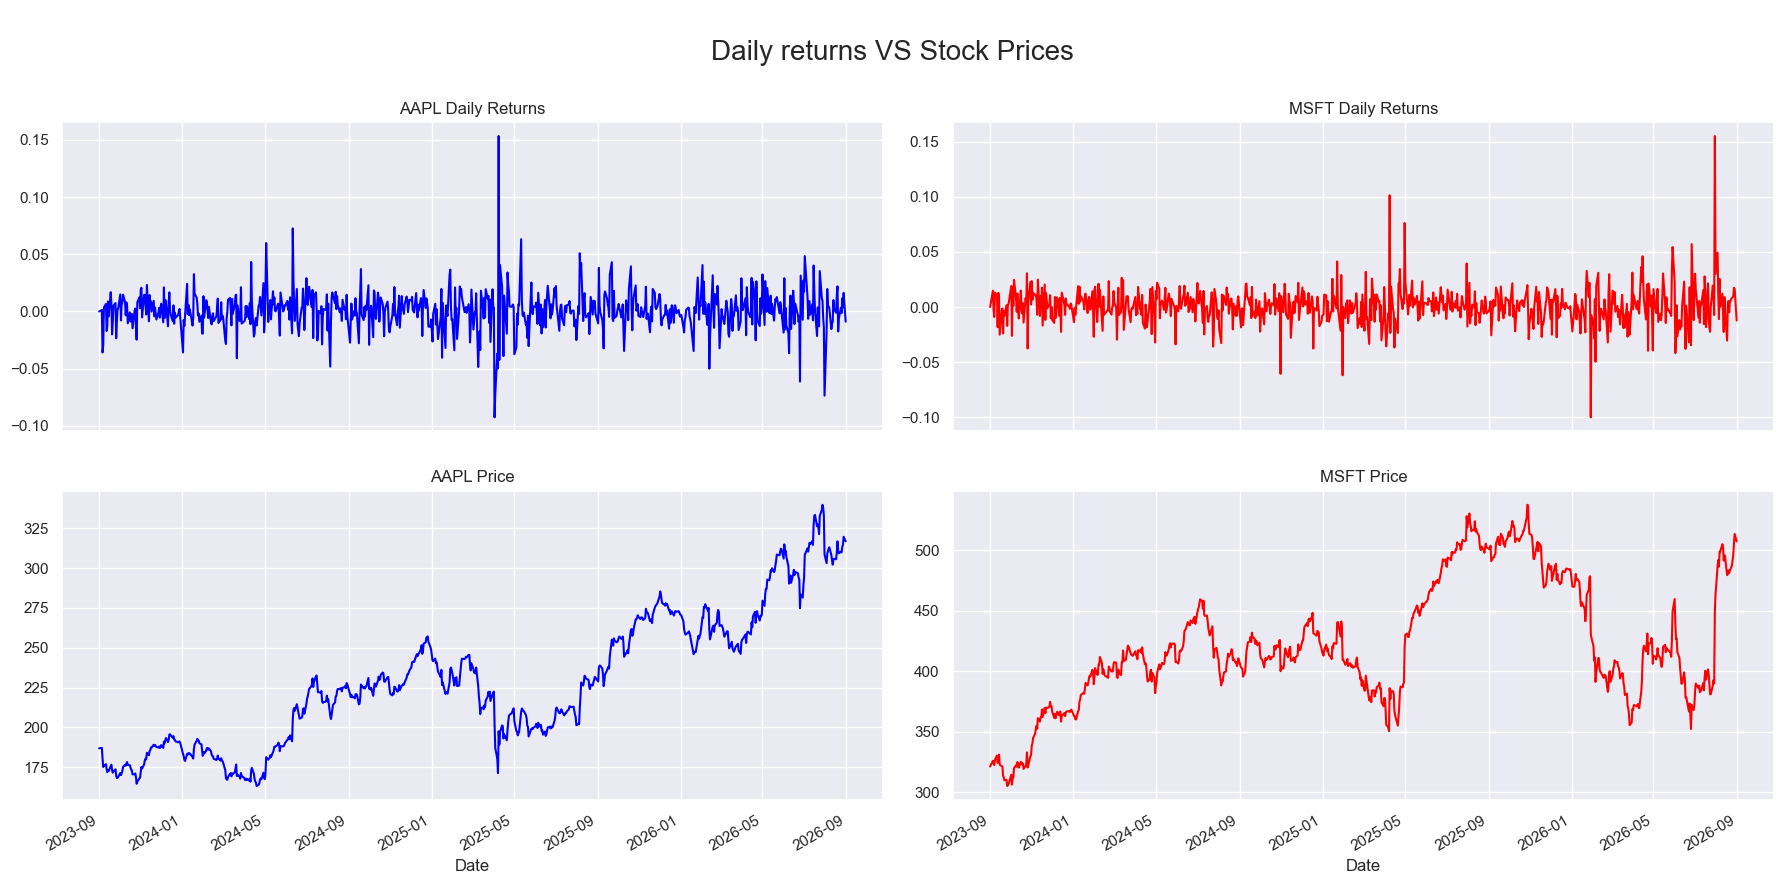

In [42]:
fig, ax = plt.subplots(2,2, figsize= (18,9), sharex= True)

Daily_Returns.AAPL.plot(ax=ax[0][0], color= 'blue')
ax[0][0].set_title('\nAAPL Daily Returns')

Daily_Returns.MSFT.plot(ax=ax[0][1], color= 'red')
ax[0][1].set_title('\nMSFT Daily Returns')


df.AAPL.plot(kind='line', ax=ax[1][0], color= 'blue')
ax[1][0].set_title('\nAAPL Price')

df.MSFT.plot(kind='line', ax=ax[1][1], color= 'red')
ax[1][1].set_title('\nMSFT Price')

fig.suptitle('\nDaily returns VS Stock Prices', fontsize= 20)
plt.tight_layout()




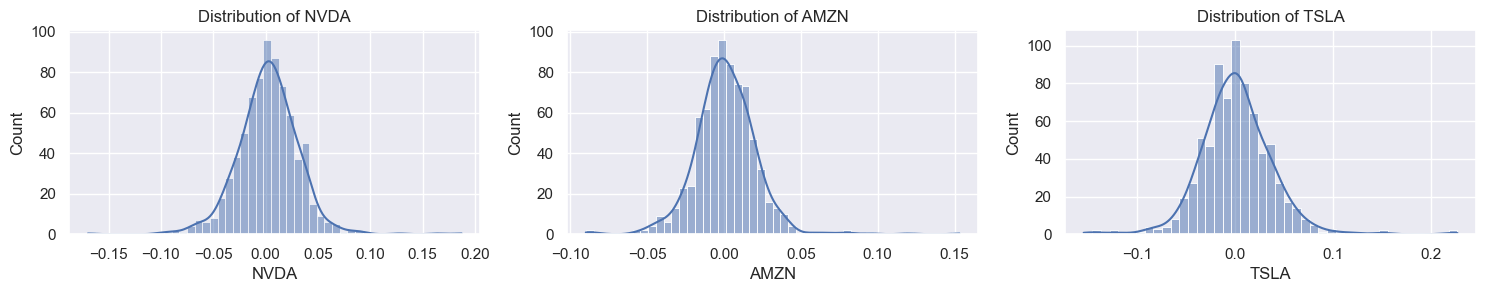

In [24]:
plt.figure(figsize=(20,8))
for e, i in enumerate(Daily_Returns[['NVDA', 'AMZN', 'TSLA']]):
    plt.subplot(3, 4, e+1)
    sns.histplot(Daily_Returns[i], kde= True)
    plt.title('Distribution of ' + i)
    plt.tight_layout()

In [25]:
df.head()

,AAPL,MSFT,NVDA,AMZN,TSLA
Date,,,,,
2023-09-01,186.93,321.14,48.41,138.12,245.01
2023-09-05,187.17,325.92,48.45,137.27,256.49
2023-09-06,180.47,325.26,46.97,135.36,251.92
2023-09-07,175.19,322.36,46.15,137.85,251.49
2023-09-08,175.80,326.62,45.49,138.23,248.50


In [26]:
stocknames = df.columns

for stock in stocknames:

    cumulative_return = (
        (df.iloc[-1][stock] / df.iloc[0][stock]) - 1
    ) * 100

    print(
        'Cumulative return of {} is: {}%'.format(
            stock,
            round(cumulative_return, 2)
        )
    )

Cumulative return of AAPL is: 69.5%
Cumulative return of MSFT is: 57.97%
Cumulative return of NVDA is: 356.02%
Cumulative return of AMZN is: 88.08%
Cumulative return of TSLA is: 50.18%


# Cumulative Return Analysis

## Overview

Cumulative return was calculated to measure the overall percentage change in each stock's closing price over the entire analysis period.

The cumulative return was calculated using the following formula:

$$
Cumulative\ Return =
\left(\frac{Final\ Price}{Initial\ Price}-1\right)\times100
$$

This metric provides a clear view of the total historical performance of each stock during the selected period.

---

## Results

| Stock | Cumulative Return |
|:---|---:|
| NVDA | **356.02%** |
| AMZN | **88.08%** |
| AAPL | **69.50%** |
| MSFT | **57.97%** |
| TSLA | **50.18%** |

---

## Key Findings

### 1. NVIDIA (NVDA)

NVDA achieved the highest cumulative return at **356.02%**, significantly outperforming all other stocks during the analysis period.

This indicates exceptionally strong historical price growth. However, NVDA also showed relatively high volatility, meaning that the higher return was accompanied by higher historical risk.

### 2. Amazon (AMZN)

AMZN recorded a cumulative return of **88.08%**, making it the second-best performing stock in terms of total return.

Amazon demonstrated a moderate risk profile compared with NVDA and TSLA, which may indicate a relatively balanced historical risk-return relationship.

### 3. Apple (AAPL)

AAPL achieved a cumulative return of **69.50%**.

Combined with its relatively low volatility, Apple demonstrated a potentially attractive historical balance between return and risk.

### 4. Microsoft (MSFT)

MSFT recorded a cumulative return of **57.97%**.

Microsoft also showed the lowest historical volatility among the five stocks, indicating relatively stable daily price movements.

### 5. Tesla (TSLA)

TSLA recorded a cumulative return of **50.18%**, which was the lowest among the five stocks during the analyzed period.

Despite having the highest historical volatility, Tesla generated the lowest cumulative return among the selected stocks. This suggests that higher volatility does not necessarily guarantee higher returns.

---

## Performance Ranking

Based on cumulative return, the stocks are ranked as follows:

🥇 **NVDA — 356.02%**

🥈 **AMZN — 88.08%**

🥉 **AAPL — 69.50%**

4️⃣ **MSFT — 57.97%**

5️⃣ **TSLA — 50.18%**

---

## Business Insight

The cumulative return analysis highlights significant differences in historical stock performance.

**NVDA** delivered the strongest historical growth but with relatively high volatility.

**AAPL and AMZN** showed strong cumulative returns with lower volatility than NVDA and TSLA.

**MSFT** demonstrated the lowest volatility, making it historically more stable, although its cumulative return was lower than NVDA, AMZN, and AAPL.

**TSLA** had the highest volatility but the lowest cumulative return during the analysis period. This demonstrates that taking higher risk does not always result in higher returns.

---

## Conclusion

The cumulative return analysis shows that **NVDA was the strongest-performing stock** during the selected period, generating a total return of **356.02%**.

However, investment performance should not be evaluated using return alone. The results should be combined with volatility and other risk metrics to determine which stock provided the most attractive historical **risk-return profile**.

The next stage of the analysis can combine **Cumulative Return and Risk (Standard Deviation)** to visually compare the historical performance and risk of all five stocks.

## Kurtosis & Risk/Return

# NVDA

In [29]:
print(f'The mean of NVDA DR= {Daily_Returns.NVDA.mean() * 100}')
print(f'The STD of NVDA DR= {Daily_Returns.NVDA.std()}')
print(f'The Kurtosis of NVDA DR= {Daily_Returns.NVDA.kurtosis()}')

The mean of NVDA DR= 0.24572010219390206
The STD of NVDA DR= 0.0295544896051104
The Kurtosis of NVDA DR= 4.95826556471862


# TSLA

In [30]:
print(f'The mean of TSLA DR= {Daily_Returns.TSLA.mean() * 100}')
print(f'The STD of TSLA DR= {Daily_Returns.TSLA.std()}')
print(f'The Kurtosis of TSLA DR= {Daily_Returns.TSLA.kurtosis()}')

The mean of TSLA DR= 0.12087460746259908
The STD of TSLA DR= 0.036729433448631
The Kurtosis of TSLA DR= 4.860035075817811


# AMZN

In [31]:
print(f'The mean of AMZN DR= {Daily_Returns.AMZN.mean() * 100}')
print(f'The STD of AMZN DR= {Daily_Returns.AMZN.std()}')
print(f'The Kurtosis of AMZN DR= {Daily_Returns.AMZN.kurtosis()}')

The mean of AMZN DR= 0.10473614182875074
The STD of AMZN DR= 0.0203971360615079
The Kurtosis of AMZN DR= 7.298965596318315


# AAPL

In [48]:
print(f'The mean of AAPL DR= {Daily_Returns.AAPL.mean() * 100}')
print(f'The STD of AAPL DR= {Daily_Returns.AAPL.std()}')
print(f'The Kurtosis of AAPL DR= {Daily_Returns.AAPL.kurtosis()}')

The mean of AAPL DR= 0.08448462431306224
The STD of AAPL DR= 0.016908581190113674
The Kurtosis of AAPL DR= 11.509645873298844


# MSFT

In [49]:
print(f'The mean of MSFT DR= {Daily_Returns.MSFT.mean() * 100}')
print(f'The STD of MSFT DR= {Daily_Returns.MSFT.std()}')
print(f'The Kurtosis of MSFT DR= {Daily_Returns.MSFT.kurtosis()}')

The mean of MSFT DR= 0.07436086733645314
The STD of MSFT DR= 0.016501208342240562
The Kurtosis of MSFT DR= 14.269853658781125


# Daily Returns, Volatility & Risk Analysis

## Objective

The objective of this analysis is to evaluate the daily return behavior and historical risk of five stocks: **AAPL, MSFT, NVDA, AMZN, and TSLA**.

Daily returns were calculated using the percentage change in closing prices:

$$
Daily\ Return_t = \frac{Price_t}{Price_{t-1}} - 1
$$

The analysis focuses on **Mean, Standard Deviation, and Kurtosis** to understand return behavior, volatility, and tail risk.

---

## Key Findings

### 1. Average Daily Return

The mean daily returns are approximately **0%** for all five stocks. This indicates that the average daily return is relatively small over the analyzed period.

Therefore, mean daily return should not be used alone to determine which stock is more attractive.

### 2. Volatility & Risk

**Standard Deviation** is used as the primary measure of historical volatility. A higher standard deviation indicates larger day-to-day price fluctuations and higher historical risk.

| Stock | Standard Deviation | Risk Level |
| :---- | -----------------: | :--------- |
| TSLA  |             0.0367 | Highest    |
| NVDA  |             0.0296 | High       |
| AMZN  |             0.0204 | Moderate   |
| AAPL  |             0.0169 | Low        |
| MSFT  |             0.0165 | Lowest     |

Based on historical volatility, **TSLA has the highest risk**, while **MSFT has the lowest volatility** among the five stocks.

### 3. Kurtosis & Tail Risk

Kurtosis is used to identify heavy tails and extreme observations in the return distributions.

Higher kurtosis indicates a greater tendency toward extreme return observations and therefore higher **tail risk**.

| Stock | Kurtosis |
| :---- | -------: |
| MSFT  |    14.27 |
| AAPL  |    11.51 |
| AMZN  |     7.30 |
| NVDA  |     4.96 |
| TSLA  |     4.86 |

An important finding is that **volatility and tail risk are not the same thing**.

For example, **MSFT has the lowest standard deviation but the highest kurtosis**. This indicates relatively stable typical daily movements while still showing comparatively higher exposure to extreme return events.

---

## Business Insight

From a historical risk perspective:

* **TSLA and NVDA** show higher daily volatility and greater short-term price fluctuations.
* **AMZN** shows a moderate volatility profile.
* **AAPL and MSFT** show lower historical volatility.
* **MSFT and AAPL** show the highest kurtosis, indicating greater tail risk compared with the other stocks.

Therefore, selecting a stock should not be based on volatility alone. **Return, volatility, tail risk, and risk-adjusted performance should be evaluated together.**

---

## Conclusion

The analysis provides an initial assessment of the historical risk characteristics of the five stocks.

**TSLA has the highest historical volatility, while MSFT has the lowest.** However, the kurtosis analysis demonstrates that lower volatility does not necessarily eliminate the risk of extreme price movements.

The next step is to perform a **Risk–Return Analysis** using **Annualized Return, Annualized Volatility, Sharpe Ratio, and Maximum Drawdown** to identify which stocks historically provided the most attractive return relative to the risk taken.


## Risk/Return

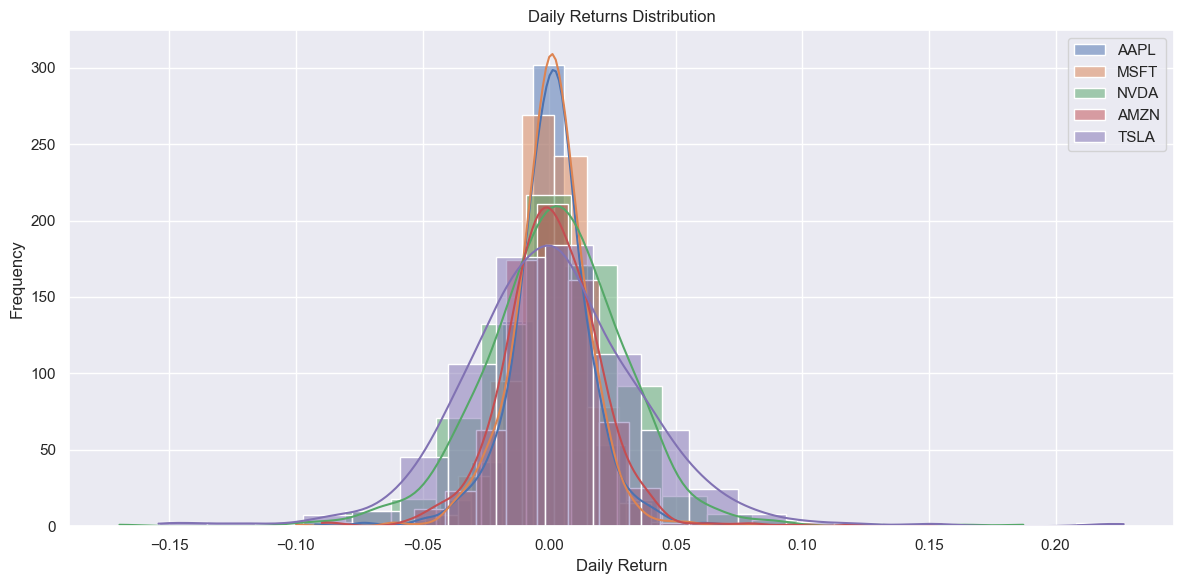

In [46]:
plt.figure(figsize=(12, 6))

sns.histplot(Daily_Returns["AAPL"], kde=True, bins=20, label="AAPL")
sns.histplot(Daily_Returns["MSFT"], kde=True, bins=20, label="MSFT")
sns.histplot(Daily_Returns["NVDA"], kde=True, bins=20, label="NVDA")
sns.histplot(Daily_Returns["AMZN"], kde=True, bins=20, label="AMZN")
sns.histplot(Daily_Returns["TSLA"], kde=True, bins=20, label="TSLA")

plt.title("Daily Returns Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

# Daily Returns Distribution Analysis

## Overview

The histogram below compares the distribution of daily returns for **AAPL, MSFT, NVDA, AMZN, and TSLA**.

The distributions are visualized using histograms with KDE curves to understand the typical daily movements, dispersion, and extreme return behavior of each stock.

## Key Observations

### 1. Distribution Center

The daily returns of all five stocks are concentrated around **0%**, indicating that most daily price movements are relatively small.

This is expected in daily stock-return data, where large positive or negative movements occur less frequently than small movements.

### 2. Volatility Comparison

The width of each distribution provides a visual indication of volatility.

- **TSLA** shows one of the widest distributions, indicating high daily volatility.
- **NVDA** also shows a relatively wide distribution, reflecting higher day-to-day price fluctuations.
- **AMZN** has moderate dispersion compared with TSLA and NVDA.
- **AAPL and MSFT** have narrower distributions, indicating lower typical daily volatility.

Therefore, the visual analysis supports the Standard Deviation results obtained earlier:

**TSLA → Highest Volatility**  
**NVDA → High Volatility**  
**AMZN → Moderate Volatility**  
**AAPL → Low Volatility**  
**MSFT → Lowest Volatility**

### 3. Extreme Returns

The tails of the distributions show that some stocks experienced larger positive and negative daily movements.

**TSLA and NVDA** display wider tails, indicating greater exposure to large daily price movements.

This supports the conclusion that these stocks have higher short-term market risk.

### 4. KDE Curves

The KDE curves provide a smoothed representation of the return distributions.

Stocks with **narrower and more concentrated curves** tend to have lower volatility, while stocks with **wider and flatter curves** tend to have higher volatility.

The KDE curves also show that the return distributions are not perfectly identical across the five companies.

## Business Insight

The distribution analysis provides a clear visual comparison of historical market risk.

For a **lower-volatility strategy**, AAPL and MSFT demonstrate more stable daily-return distributions.

For investors or organizations willing to accept **higher short-term fluctuations**, NVDA and TSLA provide higher-volatility profiles.

However, volatility alone should not be used to select an investment. The return generated relative to the risk taken should also be considered.

## Conclusion

The Daily Returns Distribution analysis confirms that the five stocks have different levels of historical volatility.

**TSLA and NVDA** experienced the widest daily-return distributions, while **AAPL and MSFT** showed more concentrated distributions.

These findings are consistent with the Standard Deviation analysis and provide a visual representation of the differences in historical risk between the stocks.

The next stage is to combine **Return and Risk metrics** to determine which stocks have historically offered the most attractive **Risk–Return Profile**.

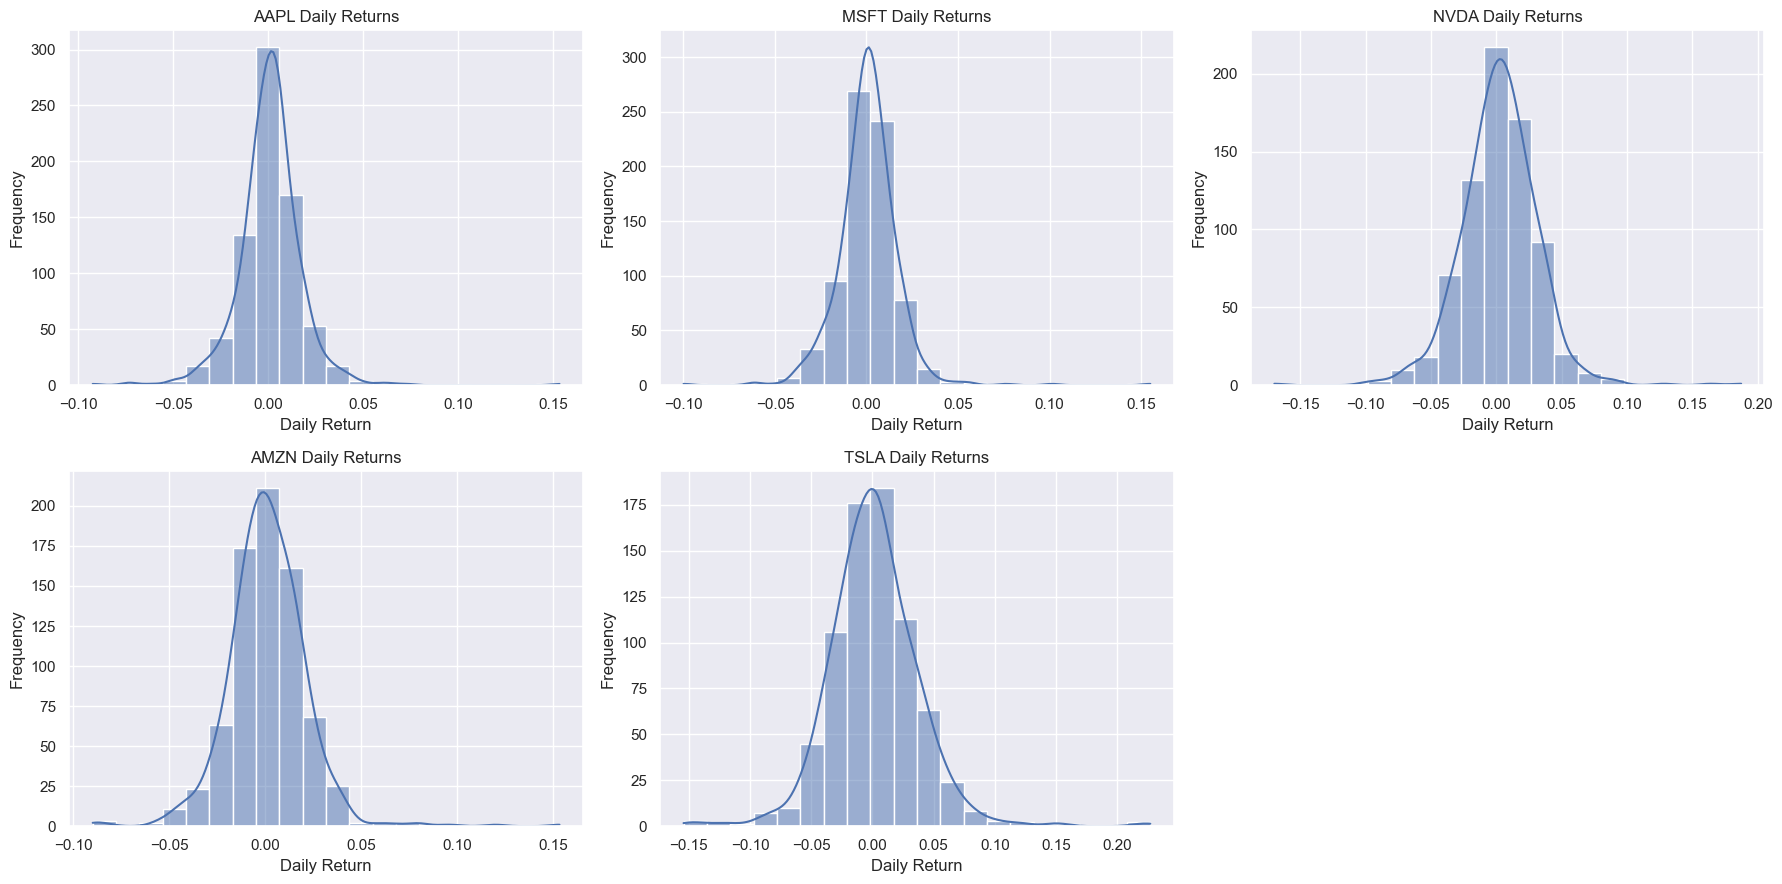

In [47]:
fig, ax = plt.subplots(2, 3, figsize=(18, 9))

companies = ["AAPL", "MSFT", "NVDA", "AMZN", "TSLA"]

for i, company in enumerate(companies):

    row = i // 3
    col = i % 3

    sns.histplot(
        Daily_Returns[company],
        kde=True,
        bins=20,
        ax=ax[row, col]
    )

    ax[row, col].set_title(f"{company} Daily Returns")
    ax[row, col].set_xlabel("Daily Return")
    ax[row, col].set_ylabel("Frequency")

ax[1, 2].set_visible(False)

plt.tight_layout()
plt.show()

In [53]:
correlation = Daily_Returns.corr()

correlation

,AAPL,MSFT,NVDA,AMZN,TSLA
AAPL,1.00,0.35,0.31,0.37,0.38
MSFT,0.35,1.00,0.43,0.53,0.31
NVDA,0.31,0.43,1.00,0.44,0.37
AMZN,0.37,0.53,0.44,1.00,0.39
TSLA,0.38,0.31,0.37,0.39,1.00


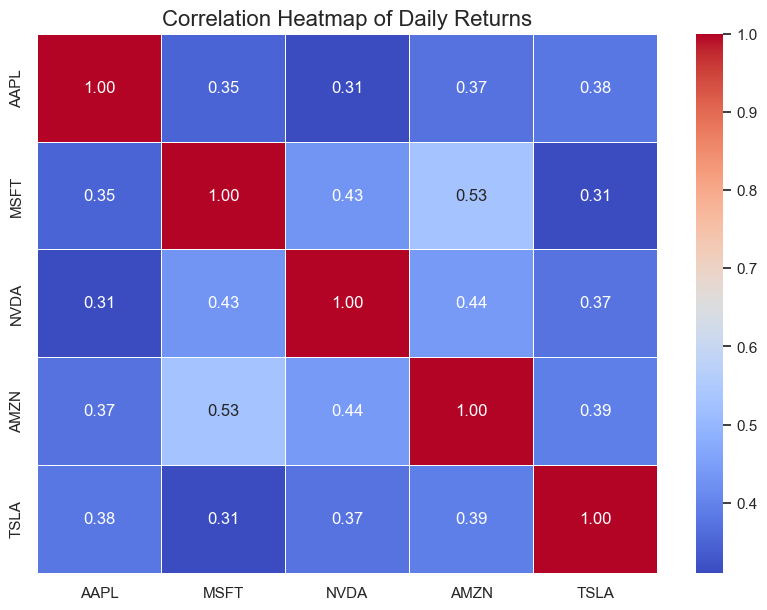

In [54]:

correlation = Daily_Returns.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Daily Returns", fontsize=16)

plt.show()

# Correlation Analysis

## Overview

Correlation analysis was performed using the daily returns of AAPL, MSFT, NVDA, AMZN, and TSLA to measure the relationship between their daily price movements.

Correlation values range from **-1 to +1**:

- **+1:** Perfect positive correlation.
- **0:** No linear relationship.
- **-1:** Perfect negative correlation.

---

## Key Findings

All correlations between the analyzed stocks are positive, ranging from approximately **0.31 to 0.53**.

This indicates that the stocks tend to move in the same direction to some extent, although the relationships are generally weak to moderate rather than extremely strong.

The highest correlation was observed between:

**MSFT and AMZN = 0.53**

This represents a moderate positive relationship between their daily returns.

The lowest correlation was observed between:

**MSFT and TSLA = 0.31**

This indicates a weaker relationship compared with the other stock pairs.

---

## Business Insight

Correlation analysis is particularly useful for portfolio diversification.

Stocks with lower correlations may provide better diversification benefits because their returns are less likely to move together.

Although all analyzed stocks have positive correlations, the correlation values are not extremely high. This suggests that combining these stocks may still provide some diversification benefits.

However, portfolio decisions should not be based on correlation alone. Return, volatility, and other risk measures should also be considered.

---

## Conclusion

The correlation analysis shows that the five stocks have weak to moderate positive relationships with each other.

**MSFT and AMZN** have the strongest relationship, while **MSFT and TSLA** have the weakest relationship.

These findings can support portfolio diversification analysis and help identify stocks that may provide diversification benefits when combined with other investments.

In [55]:
# Number of trading days in a year
trading_days = 252

# Annualized Return
annual_return = Daily_Returns.mean() * trading_days

# Annualized Volatility
annual_volatility = Daily_Returns.std() * (trading_days ** 0.5)

# Sharpe Ratio
sharpe_ratio = annual_return / annual_volatility

# Create DataFrame
sharpe_analysis = pd.DataFrame({
    "Annualized Return": annual_return,
    "Annualized Volatility": annual_volatility,
    "Sharpe Ratio": sharpe_ratio
})

sharpe_analysis

,Annualized Return,Annualized Volatility,Sharpe Ratio
AAPL,0.21,0.27,0.79
MSFT,0.19,0.26,0.72
NVDA,0.62,0.47,1.32
AMZN,0.26,0.32,0.82
TSLA,0.30,0.58,0.52


In [56]:

sharpe_df = sharpe_analysis.reset_index()

sharpe_df.columns = [
    "Stock",
    "Annualized Return",
    "Annualized Volatility",
    "Sharpe Ratio"
]

fig = px.bar(
    sharpe_df,
    x="Stock",
    y="Sharpe Ratio",
    text="Sharpe Ratio",
    title="Sharpe Ratio Comparison Across Stocks",
    width=900,
    height=500
)

fig.update_traces(
    texttemplate="%{text:.2f}",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Stock",
    yaxis_title="Sharpe Ratio"
)

fig.show()

# Sharpe Ratio Analysis

## Overview

The Sharpe Ratio analysis was performed to evaluate the risk-adjusted performance of **AAPL, MSFT, NVDA, AMZN, and TSLA**.

Unlike cumulative or annualized return alone, the Sharpe Ratio considers both **return and volatility**, providing a more balanced measure of investment performance.

The analysis assumes a **risk-free rate of 0%**.

The Sharpe Ratio is calculated as:

$$
Sharpe\ Ratio =
\frac{Annualized\ Return}{Annualized\ Volatility}
$$

A higher Sharpe Ratio indicates better return relative to the level of risk taken.

---

## Results

| Stock | Annualized Return | Annualized Volatility | Sharpe Ratio |
|:---|---:|---:|---:|
| NVDA | 62% | 47% | **1.32** |
| AMZN | 26% | 32% | **0.82** |
| AAPL | 21% | 27% | **0.79** |
| MSFT | 19% | 26% | **0.72** |
| TSLA | 30% | 58% | **0.52** |

---

## Key Findings

### 1. NVIDIA (NVDA)

NVDA achieved the highest Sharpe Ratio of **1.32**, making it the strongest performer on a risk-adjusted basis during the analyzed period.

Although NVDA experienced relatively high volatility, its annualized return of **62%** was sufficiently high to compensate for the additional risk.

Therefore, NVDA demonstrated the best historical balance between return and risk among the five analyzed stocks.

---

### 2. Amazon (AMZN)

AMZN recorded a Sharpe Ratio of **0.82**, representing the second-best risk-adjusted performance.

With an annualized return of **26%** and annualized volatility of **32%**, AMZN demonstrated a relatively balanced relationship between return and risk.

---

### 3. Apple (AAPL)

AAPL achieved a Sharpe Ratio of **0.79**.

Apple combined relatively low volatility with a solid annualized return, resulting in a strong and balanced risk-adjusted performance.

---

### 4. Microsoft (MSFT)

MSFT recorded a Sharpe Ratio of **0.72**.

Microsoft had the lowest annualized volatility among the five stocks, indicating relatively stable price movements. However, its annualized return was also lower than NVDA, AMZN, and AAPL.

---

### 5. Tesla (TSLA)

TSLA recorded the lowest Sharpe Ratio of **0.52**.

Despite generating an annualized return of **30%**, Tesla experienced the highest annualized volatility at **58%**.

This result demonstrates that higher returns alone do not necessarily lead to better investment performance when the associated risk is also high.

---

## Risk-Adjusted Performance Ranking

Based on the Sharpe Ratio:

🥇 **NVDA — 1.32**

🥈 **AMZN — 0.82**

🥉 **AAPL — 0.79**

4️⃣ **MSFT — 0.72**

5️⃣ **TSLA — 0.52**

---

## Business Insight

The Sharpe Ratio analysis demonstrates the importance of evaluating both return and risk.

A stock may generate a high return but still provide weaker risk-adjusted performance if it experiences excessive volatility.

NVDA delivered the strongest historical risk-adjusted performance during the analyzed period.

AMZN and AAPL demonstrated relatively balanced risk-return profiles.

MSFT showed lower volatility and greater historical stability but generated a lower return.

TSLA experienced the highest volatility and the weakest risk-adjusted performance among the five stocks.

---

## Conclusion

Based on the historical data analyzed, **NVDA achieved the strongest risk-adjusted performance**, as indicated by the highest Sharpe Ratio of **1.32**.

However, these results are based on historical performance and should not be interpreted as a guarantee of future investment performance.

The Sharpe Ratio analysis completes the comparison between **return, volatility, and risk-adjusted performance**, providing a stronger foundation for evaluating the overall historical performance of the five stocks.

In [59]:
# Calculate Maximum Drawdown
rolling_max = df.cummax()

drawdown = (df / rolling_max) - 1

max_drawdown = drawdown.min()

# Convert to percentage
max_drawdown_percent = max_drawdown * 100

# Create DataFrame for analysis
max_drawdown_analysis = pd.DataFrame({
    "Maximum Drawdown (%)": max_drawdown_percent
})

max_drawdown_analysis

,Maximum Drawdown (%)
AAPL,-33.36
MSFT,-34.50
NVDA,-36.88
AMZN,-30.88
TSLA,-53.77


In [60]:

mdd_df = max_drawdown_analysis.reset_index()

mdd_df.columns = [
    "Stock",
    "Maximum Drawdown (%)"
]

fig = px.bar(
    mdd_df,
    x="Stock",
    y="Maximum Drawdown (%)",
    text="Maximum Drawdown (%)",
    title="Maximum Drawdown Comparison Across Stocks",
    width=900,
    height=500
)

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Stock",
    yaxis_title="Maximum Drawdown (%)"
)

fig.show()

# Maximum Drawdown Analysis

## Overview

Maximum Drawdown was calculated to measure the largest historical decline in each stock's price from a previous peak to a subsequent trough during the analysis period.

Maximum Drawdown is an important downside risk metric because it shows the maximum loss an investor could have experienced before the stock recovered.

The Drawdown is calculated as:

$$
Drawdown_t =
\frac{Price_t}{Rolling\ Maximum_t} - 1
$$

The Maximum Drawdown represents the most negative drawdown value during the analyzed period.

---

## Results

| Stock | Maximum Drawdown |
|:---|---:|
| AMZN | **-30.88%** |
| AAPL | **-33.36%** |
| MSFT | **-34.50%** |
| NVDA | **-36.88%** |
| TSLA | **-53.77%** |

---

## Key Findings

### 1. Amazon (AMZN)

AMZN recorded the lowest Maximum Drawdown at **-30.88%**.

This indicates that Amazon experienced the smallest peak-to-trough decline among the five analyzed stocks, suggesting relatively lower downside risk during the selected period.

---

### 2. Apple (AAPL)

AAPL experienced a Maximum Drawdown of **-33.36%**.

Although Apple demonstrated relatively low daily volatility, the stock still experienced a significant decline from a previous peak during the analysis period.

This demonstrates that lower daily volatility does not completely eliminate downside risk.

---

### 3. Microsoft (MSFT)

MSFT recorded a Maximum Drawdown of **-34.50%**.

Microsoft showed relatively stable daily price movements based on its volatility analysis, but it still experienced a substantial decline during its worst historical period.

---

### 4. NVIDIA (NVDA)

NVDA experienced a Maximum Drawdown of **-36.88%**.

Despite recording the highest cumulative return and the strongest Sharpe Ratio, NVDA also experienced a significant historical decline.

This highlights an important relationship between return and risk:

> High historical returns do not necessarily mean low downside risk.

---

### 5. Tesla (TSLA)

TSLA recorded the largest Maximum Drawdown at **-53.77%**.

This means that during the worst period of the analysis, Tesla declined by more than half of its previous peak value before recovering.

This result supports the previous volatility analysis, which identified TSLA as the most volatile stock among the five companies.

---

## Downside Risk Ranking

From the lowest downside risk to the highest:

🥇 **AMZN — -30.88%**

🥈 **AAPL — -33.36%**

🥉 **MSFT — -34.50%**

4️⃣ **NVDA — -36.88%**

5️⃣ **TSLA — -53.77%**

---

## Business Insight

Maximum Drawdown provides a different perspective on risk compared with Standard Deviation.

While Standard Deviation measures typical day-to-day price volatility, Maximum Drawdown measures the severity of the largest historical loss from a peak to a trough.

The results show that:

- **AMZN** experienced the smallest historical decline.
- **AAPL and MSFT** demonstrated moderate downside risk.
- **NVDA** generated exceptional returns but also experienced significant downside risk.
- **TSLA** showed the highest downside risk, confirming its high-risk profile.

Therefore, investment decisions should consider both **potential returns and potential losses**.

---

## Conclusion

The Maximum Drawdown analysis confirms that risk cannot be measured using a single metric.

A complete risk evaluation should combine:

- **Volatility (Standard Deviation)**
- **Tail Risk (Kurtosis)**
- **Downside Risk (Maximum Drawdown)**
- **Risk-Adjusted Performance (Sharpe Ratio)**

Among the analyzed stocks, **AMZN showed the lowest Maximum Drawdown**, while **TSLA showed the highest downside risk**.

These results provide an additional layer of risk analysis and help create a more comprehensive evaluation of the historical performance of the five stocks.

In [67]:
df.to_csv("combined_close_prices.csv")

# Final Conclusion and Business Insights

## Project Summary

This project analyzed approximately three years of historical stock market data for five major companies:

- Apple (AAPL)
- Microsoft (MSFT)
- NVIDIA (NVDA)
- Amazon (AMZN)
- Tesla (TSLA)

The analysis focused on comparing stock performance, returns, volatility, correlations, risk-adjusted performance, and downside risk.

Several analytical techniques and financial metrics were used, including:

- Daily Returns
- Volatility
- Kurtosis
- Cumulative Returns
- Correlation Analysis
- Sharpe Ratio
- Maximum Drawdown

---

## Key Findings

### NVIDIA (NVDA)

NVDA achieved the strongest overall historical performance among the analyzed stocks.

It recorded:

- The highest cumulative return of approximately **356%**.
- The highest annualized return.
- The highest Sharpe Ratio of **1.32**.

Although NVDA experienced relatively high volatility and a Maximum Drawdown of approximately **-36.88%**, its strong returns resulted in the best risk-adjusted performance among the five stocks.

---

### Amazon (AMZN)

AMZN demonstrated a relatively balanced risk-return profile.

It achieved:

- A cumulative return of approximately **88%**.
- A Sharpe Ratio of **0.82**.
- The lowest Maximum Drawdown of **-30.88%**.

These results suggest that AMZN provided a relatively balanced combination of return and downside risk during the analyzed period.

---

### Apple (AAPL)

AAPL demonstrated a relatively stable and balanced performance.

It achieved:

- A cumulative return of approximately **69.5%**.
- A Sharpe Ratio of **0.79**.
- Relatively low volatility compared with NVDA and TSLA.

Apple may be considered one of the more balanced stocks in terms of historical return and risk.

---

### Microsoft (MSFT)

MSFT demonstrated the lowest volatility among the analyzed stocks.

It achieved:

- A cumulative return of approximately **58%**.
- A Sharpe Ratio of **0.72**.

Microsoft showed relatively stable historical price movements, although its overall return was lower than NVDA, AMZN, and AAPL.

---

### Tesla (TSLA)

TSLA demonstrated the highest level of historical risk.

It recorded:

- The highest annualized volatility.
- The largest Maximum Drawdown of approximately **-53.77%**.
- The lowest Sharpe Ratio of **0.52**.

Although TSLA generated positive returns during the analyzed period, its high volatility and significant downside risk resulted in the weakest risk-adjusted performance among the five stocks.

---

## Overall Comparison

Based on the historical analysis:

🥇 **Best Overall Risk-Adjusted Performance: NVDA**

NVDA achieved the highest Sharpe Ratio and the strongest overall return performance.

🥈 **Most Balanced Risk and Return: AMZN**

AMZN demonstrated a strong balance between return and downside risk.

🥉 **Relatively Stable and Balanced: AAPL**

AAPL provided relatively stable performance with a reasonable balance between risk and return.

🟢 **Most Stable Stock: MSFT**

MSFT showed the lowest volatility among the analyzed companies.

🔴 **Highest Historical Risk: TSLA**

TSLA recorded the highest volatility and the largest Maximum Drawdown.

---

## Final Business Insight

The analysis demonstrates that investment performance should not be evaluated based on return alone.

A comprehensive evaluation should consider multiple factors, including:

- Expected or historical returns
- Volatility
- Tail risk
- Correlation with other assets
- Risk-adjusted performance
- Maximum potential historical losses

For example, NVDA generated the highest returns and the strongest risk-adjusted performance, while TSLA demonstrated that a positive return does not necessarily indicate an attractive risk profile when volatility and downside risk are significantly higher.

---

## Final Conclusion

Based on the historical data analyzed, **NVDA demonstrated the strongest overall performance**, particularly in terms of cumulative return and risk-adjusted return.

**AMZN and AAPL demonstrated relatively balanced risk-return profiles**, while **MSFT showed the greatest historical stability due to its lower volatility**.

**TSLA demonstrated the highest level of historical risk**, based on both volatility and Maximum Drawdown.

It is important to note that these findings are based entirely on historical data. Past performance does not guarantee future results, and this analysis should not be considered financial or investment advice.

This project demonstrates how Python and data analysis techniques can be used to transform historical financial data into meaningful insights regarding stock performance, risk, and return.